# 🏠 House Price Prediction — Internship Project (Week 1)

**Goal:** Build a regression model that predicts house prices from property features (size, rooms, location-related amenities, age-related structure) and identify which features matter most.

**Dataset:** `Housing.csv` — 545 property records, 13 columns (Kaggle: *Housing Prices Dataset*).


## Task 1 — Data Loading & Exploration

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("Housing.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset shape: 545 rows, 13 columns


In [ ]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
print("Column data types:\n")
print(df.dtypes)

print("\nTarget variable : price")
print("Feature variables:", [c for c in df.columns if c != "price"])

Column data types:

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Target variable : price
Feature variables: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [5]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


## Task 2 — Data Cleaning

The missing-value check above shows the dataset has **no missing values**, but i keep
the handling logic below so the notebook is robust if the CSV changes (e.g. re-downloaded
with new rows).

In [6]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ["int64", "float64"]:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

before = len(df)
df = df.drop_duplicates()
print(f"Duplicate rows removed: {before - len(df)}")
print(f"Shape after cleaning: {df.shape}")

Duplicate rows removed: 0
Shape after cleaning: (545, 13)


In [7]:
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating",
               "airconditioning", "prefarea"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})


df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)


print("Columns used for modeling:")
print(list(df.columns))

Columns used for modeling:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


## Task 3 — Model Building

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set    : {X_test.shape[0]} rows")

Training set: 436 rows
Test set    : 109 rows


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression performance:")
print(f"  MAE  : Rs {lr_mae:,.0f}")
print(f"  RMSE : Rs {lr_rmse:,.0f}")
print(f"  R2   : {lr_r2:.4f}")

Linear Regression performance:
  MAE  : Rs 970,043
  RMSE : Rs 1,324,507
  R2   : 0.6529


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor performance:")
print(f"  MAE  : Rs {rf_mae:,.0f}")
print(f"  RMSE : Rs {rf_rmse:,.0f}")
print(f"  R2   : {rf_r2:.4f}")

Random Forest Regressor performance:
  MAE  : Rs 1,014,947
  RMSE : Rs 1,399,769
  R2   : 0.6124


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


## Task 4 — Visualization

### Chart 1 — Distribution of House Prices

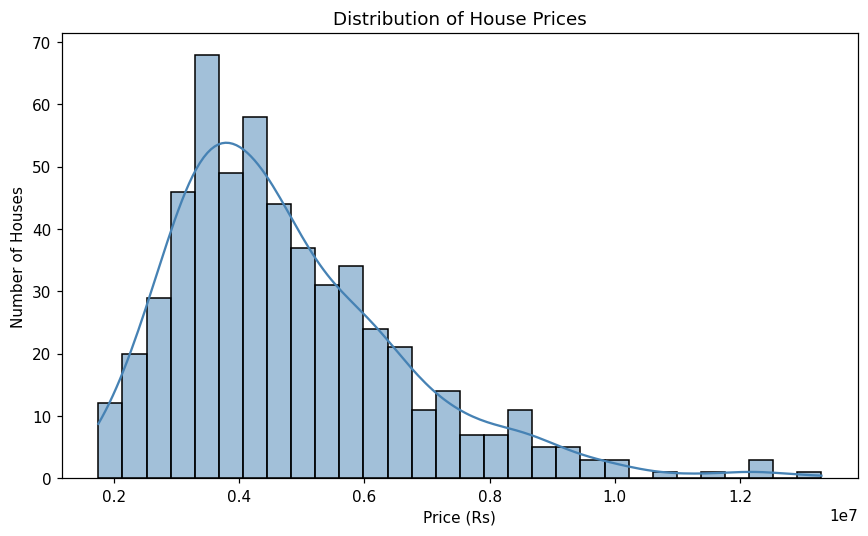

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of House Prices")
plt.xlabel("Price (Rs)")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

### Chart 2 — Correlation Heatmap

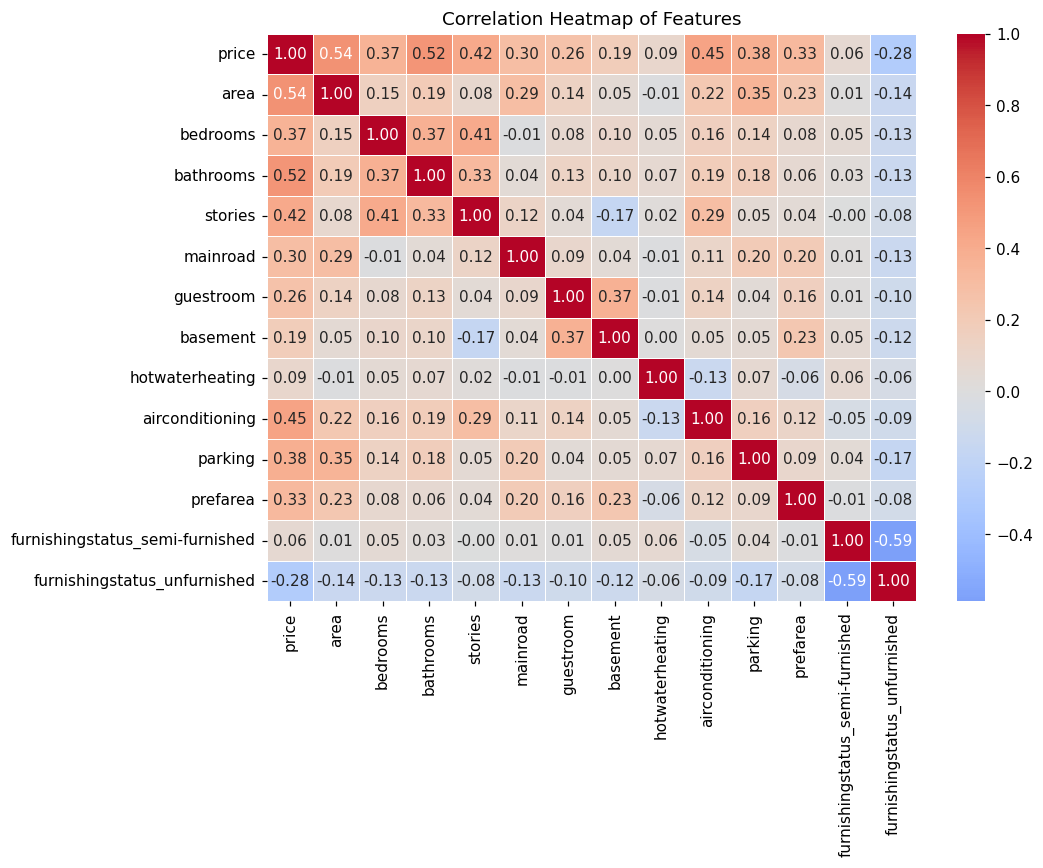

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.show()

### Chart 3 — Actual vs. Predicted Price (Linear Regression vs. Random Forest)

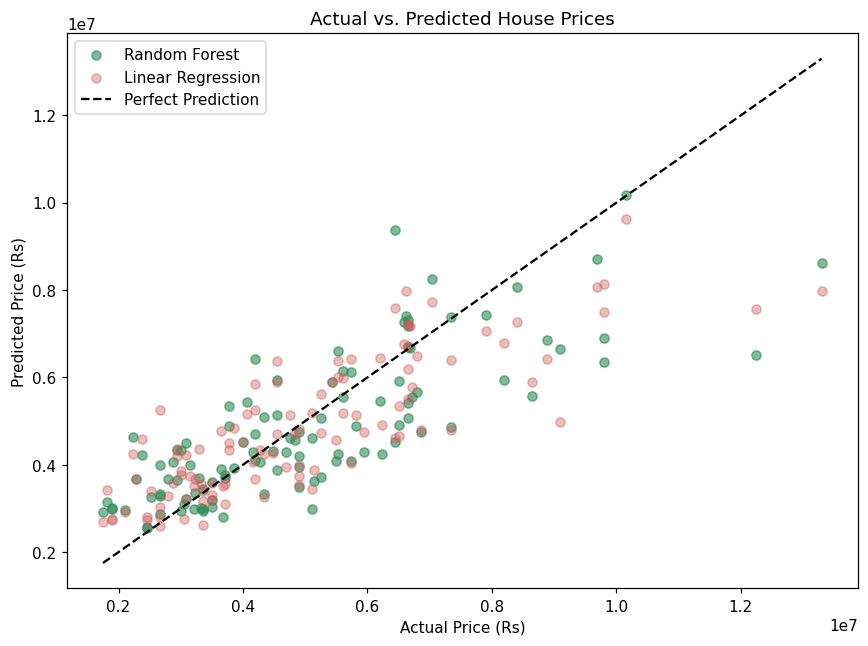

In [ ]:
plt.figure(figsize=(8, 6))
lims = [y_test.min(), y_test.max()]
plt.scatter(y_test, rf_pred, alpha=0.6, color="seagreen", label="Random Forest")
plt.scatter(y_test, lr_pred, alpha=0.4, color="indianred", label="Linear Regression")
plt.plot(lims, lims, "k--", linewidth=1.5, label="Perfect Prediction")
plt.xlabel("Actual Price (Rs)")
plt.ylabel("Predicted Price (Rs)")
plt.title("Actual vs. Predicted House Prices")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False)
feat_importance

,0
area,0.467809
bathrooms,0.152635
airconditioning,0.060260
parking,0.057557
stories,0.057045
bedrooms,0.047544
furnishingstatus_unfurnished,0.036974
basement,0.032418
prefarea,0.028316
hotwaterheating,0.018333


## Task 5 — Insights & Summary

**Which features influence price most?** `area` is by far the strongest driver
(highest correlation with price and the top feature in the Random Forest's importance
ranking), followed by `bathrooms`, `airconditioning`, and number of `stories`. Houses
on a `prefarea` (preferred area) and `mainroad` access also command a price premium.

**How accurate was the model?** The Linear Regression model explains about 65% of the
variation in price (R² ≈ 0.65) with a typical error of roughly Rs 9.7 lakh, while the
Random Forest explains about 61% (R² ≈ 0.61) with a slightly higher typical error. In
plain terms: the model gets you in the right ballpark for pricing a house, but it isn't
precise enough on its own to set a final listing price — it works best as a starting
estimate alongside a human appraisal.

**What was surprising?** The simpler Linear Regression model actually edged out the
more complex Random Forest on this dataset, which has only ~545 rows — a reminder that
more powerful models don't automatically win on small datasets. It was also notable
that an `unfurnished` status pulls price down more than `airconditioning` or a
`guestroom` pulls it up.

**Recommendation for a real estate business:** Prioritize marketing and pricing
guidance around `area`, `bathrooms`, and `airconditioning`, since these have the
largest measurable effect on price — for example, highlighting air conditioning and
extra bathrooms in listings, and using square footage as the primary anchor when
setting an initial asking price.